In [3]:
import json, re, subprocess, tempfile, shutil
from pathlib import Path

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import requests
from tqdm.auto import tqdm

OUTPUT_DIR = Path('output/dpiac_security_audit')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Root of the cloned IaCGen repo — adjust if different
BENCHMARK_CSV  = Path('Data/iac_basic.csv')
TEMPLATE_ROOT  = Path('Data/groud_truth/template')   # note: typo is in the original repo

SEV_COLORS = {
    'CRITICAL': '#B22222', 'HIGH': '#EF553B',
    'MEDIUM':   '#FFA15A', 'LOW':  '#636EFA', 'UNKNOWN': '#AAAAAA',
}


In [5]:
_TRIVY_TREE_API = (
    "https://api.github.com/repos/aquasecurity/trivy-checks/"
    "git/trees/HEAD?recursive=1"
)

def build_avd_title_map() -> dict[str, str]:
    title_map: dict[str, str] = {}
    resp = requests.get(_TRIVY_TREE_API, timeout=30)
    resp.raise_for_status()
    tree = resp.json().get('tree', [])

    # CloudFormation checks live under checks/cloud/aws/ — same AVD IDs
    rego_paths = [
        item['path'] for item in tree
        if item['path'].startswith('checks/cloud/aws/')
        and item['path'].endswith('.rego')
        and not item['path'].endswith('_test.rego')
        and 'lib/' not in item['path']
    ]
    print(f"  Found {len(rego_paths)} AWS .rego files — downloading...")
    raw_base = "https://raw.githubusercontent.com/aquasecurity/trivy-checks/HEAD/"

    for path in rego_paths:
        try:
            r = requests.get(raw_base + path, timeout=15)
            r.raise_for_status()
            content = r.text
        except Exception:
            continue
        title_match = re.search(r'^# title:\s*(.+)$',         content, re.MULTILINE)
        id_match    = re.search(r'^#\s+id:\s*(AWS-\d+)\s*$',  content, re.MULTILINE)
        if not title_match or not id_match:
            continue
        title    = title_match.group(1).strip()
        short_id = id_match.group(1).strip()
        title_map[short_id]          = title
        title_map[f"AVD-{short_id}"] = title

    print(f"  Registry built: {len(title_map)} entries")
    return title_map

AVD_TITLE_MAP = build_avd_title_map()


  Found 175 AWS .rego files — downloading...
  Registry built: 350 entries


In [31]:
_SEV_MAP = {
    'CRITICAL': 'severity_critical', 'HIGH': 'severity_high',
    'MEDIUM':   'severity_medium',   'LOW':  'severity_low',
    'UNKNOWN':  'severity_unknown',
}
_AWS_PREFIXES = ('AVD-AWS-', 'AWS-')

# Singleton checks that fire on absent-resources — exclude for per-template analysis
EXCLUDE_IDS = {
    'AWS-0056','AWS-0057','AWS-0058','AWS-0059','AWS-0060',
    'AWS-0061','AWS-0062','AWS-0063','AWS-0019','AWS-0140',
    'AWS-0141','AWS-0143','AWS-0123','AWS-0345','AWS-0346','AWS-0342',
}

def run_trivy_cfn(template_path: Path, timeout: int = 90) -> dict:
    result = dict(
        trivy_passed=False, trivy_error=None,
        total_checks=0, passed_checks=0, failed_checks=0,
        policy_pass_rate=None, fully_compliant=False,
        severity_critical=0, severity_high=0, severity_medium=0,
        severity_low=0, severity_unknown=0,
        violations=[], violation_ids=[], violation_titles=[],
    )

    if not template_path.exists():
        result['trivy_error'] = f'file_not_found: {template_path}'
        return result

    cmd = [
        'trivy', 'config',
        '--format', 'json',
        '--quiet',
        '--include-non-failures',
        str(template_path),
    ]
    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        result['trivy_error'] = 'TimeoutExpired'; return result
    except FileNotFoundError:
        result['trivy_error'] = 'trivy_not_found'; return result
    except Exception as e:
        result['trivy_error'] = str(e); return result

    try:
        raw = json.loads(proc.stdout)
    except json.JSONDecodeError:
        result['trivy_error'] = 'json_parse_failed'; return result

    results_list = raw.get('Results', [])
    use_results  = [r for r in results_list if r.get('Target', '') != '.'] or results_list

    total_passed = total_failed = 0

    for res in use_results:
        summary     = res.get('MisconfSummary', {})
        all_misconfs = res.get('Misconfigurations', [])

        valid = [
            m for m in all_misconfs
            if any(m.get('ID', '').startswith(p) for p in _AWS_PREFIXES)
            and m.get('ID', '') not in EXCLUDE_IDS
        ]

        total_failed  += len(valid)
        total_passed  += int(summary.get('Successes', 0))

        for m in valid:
            check_id    = m.get('ID', '')
            check_title = AVD_TITLE_MAP.get(check_id, m.get('Title', check_id))
            sev         = (m.get('Severity') or 'UNKNOWN').upper()
            cause       = m.get('CauseMetadata', {})
            resource    = cause.get('Resource', res.get('Target', ''))
            resource_type = resource.split('.')[0] if '.' in resource else resource

            result['violations'].append({
                'check_id':     check_id,
                'check_title':  check_title,
                'resource':     resource,
                'resource_type': resource_type,
                'severity':     sev,
                'status':       m.get('Status', ''),
                'description':  m.get('Description', ''),
                'resolution':   m.get('Resolution', ''),
            })
            result['violation_ids'].append(check_id)
            result['violation_titles'].append(check_title)
            result[_SEV_MAP.get(sev, 'severity_unknown')] += 1

    result['passed_checks']  = total_passed
    result['failed_checks']  = total_failed
    result['total_checks']   = total_passed + total_failed
    if result['total_checks'] > 0:
        result['policy_pass_rate'] = round(total_passed / result['total_checks'], 4)
    result['fully_compliant'] = result['total_checks'] > 0 and total_failed == 0
    result['trivy_passed']    = result['fully_compliant']
    return result


In [33]:
from pathlib import PureWindowsPath

df = pd.read_csv(BENCHMARK_CSV)
print(f"Loaded {len(df)} scenarios")

# Resolve absolute template paths
df['template_path'] = df['ground_truth_path'].apply(
    lambda p: TEMPLATE_ROOT / PureWindowsPath(p).name   # filename only — avoids Windows path issues
)

print(df.head(3)[['row_number','template_path','prompt']].to_string())

# Verify coverage
missing = df[~df['template_path'].apply(lambda p: p.exists())]
if len(missing):
    print(f"⚠️  {len(missing)} templates not found locally:")
    print(missing[['row_number','ground_truth_path']].to_string())
else:
    print("✅  All templates found locally")


Loaded 153 scenarios
   row_number                            template_path                                                                                                         prompt
0           0  Data/groud_truth/template/sqs_easy.yaml                      We need a CloudFormation template that creates an AWS SQS queue with basic configuration.
1           1  Data/groud_truth/template/sns_easy.yaml  We need a CloudFormation template that creates an AWS SNS with notification sending to email "test@test.com".
2           2   Data/groud_truth/template/s3_easy.yaml                               We need a CloudFormation template that creates an Amazon S3 bucket with defaults
✅  All templates found locally


In [35]:
scan_results = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Trivy CFn scan', unit='template'):
    r = run_trivy_cfn(row['template_path'])
    r['row_number'] = row['row_number']
    r['prompt']     = row['prompt']
    r['template']   = Path(row['ground_truth_path']).name
    scan_results.append(r)

SCALAR_COLS = [
    'trivy_passed','trivy_error','total_checks','passed_checks','failed_checks',
    'policy_pass_rate','fully_compliant',
    'severity_critical','severity_high','severity_medium','severity_low','severity_unknown',
]
df_scan = pd.DataFrame(scan_results)
df_result = df[['row_number','prompt']].copy()
df_result['template'] = df_scan['template']
for c in SCALAR_COLS:
    df_result[c] = df_scan[c]
df_result['violation_ids']    = df_scan['violation_ids']
df_result['violation_titles'] = df_scan['violation_titles']
df_result['violations_json']  = df_scan['violations'].apply(json.dumps)

df_result['swvs'] = (
    df_result['severity_critical'] * 4 + df_result['severity_high']     * 3 +
    df_result['severity_medium']   * 2 + df_result['severity_low']      * 1 +
    df_result['severity_unknown']  * 0.5
)

print(f"\nScan complete")
print(f"  Scenarios scanned     : {len(df_result):,}")
print(f"  Fully compliant (FCR) : {df_result['fully_compliant'].sum():,}  ({df_result['fully_compliant'].mean()*100:.1f}%)")
print(f"  Mean PPR              : {df_result['policy_pass_rate'].mean()*100:.1f}%")
print(f"  Total violations      : {df_result['failed_checks'].sum():,}")
df_result.head()

Trivy CFn scan:   0%|          | 0/153 [00:00<?, ?template/s]


Scan complete
  Scenarios scanned     : 153
  Fully compliant (FCR) : 0  (0.0%)
  Mean PPR              : 63.0%
  Total violations      : 2,902


,row_number,prompt,template,trivy_passed,trivy_error,total_checks,passed_checks,failed_checks,policy_pass_rate,fully_compliant,severity_critical,severity_high,severity_medium,severity_low,severity_unknown,violation_ids,violation_titles,violations_json,swvs
0,0,We need a CloudFormation template that creates...,Data\groud_truth\template\sqs_easy.yaml,False,None,38,26,12,0.6842,False,0,6,4,2,0,"[AWS-0096, AWS-0077, AWS-0078, AWS-0079, AWS-0...","[Unencrypted SQS queue., RDS Cluster and RDS i...","[{""check_id"": ""AWS-0096"", ""check_title"": ""Unen...",28.0
1,1,We need a CloudFormation template that creates...,Data\groud_truth\template\sns_easy.yaml,False,None,36,25,11,0.6944,False,0,5,4,2,0,"[AWS-0095, AWS-0077, AWS-0078, AWS-0079, AWS-0...","[Unencrypted SNS topic., RDS Cluster and RDS i...","[{""check_id"": ""AWS-0095"", ""check_title"": ""Unen...",25.0
2,2,We need a CloudFormation template that creates...,Data\groud_truth\template\s3_easy.yaml,False,None,45,26,19,0.5778,False,0,9,6,4,0,"[AWS-0086, AWS-0087, AWS-0089, AWS-0090, AWS-0...","[S3 Access block should block public ACL, S3 A...","[{""check_id"": ""AWS-0086"", ""check_title"": ""S3 A...",43.0
3,3,We need a CloudFormation template that creates...,Data\groud_truth\template\s3_webhost_and_delet...,False,None,46,27,19,0.5870,False,0,9,6,4,0,"[AWS-0086, AWS-0087, AWS-0089, AWS-0090, AWS-0...","[S3 Access block should block public ACL, S3 A...","[{""check_id"": ""AWS-0086"", ""check_title"": ""S3 A...",43.0
4,4,We need a CloudFormation template that creates...,Data\groud_truth\template\ec2_easy.yaml,False,None,71,42,29,0.5915,False,4,13,6,6,0,"[AWS-0028, AWS-0131, AWS-0008, AWS-0009, AWS-0...",[aws_instance should activate session tokens f...,"[{""check_id"": ""AWS-0028"", ""check_title"": ""aws_...",73.0


In [37]:
# ── Annotated table: each scenario gets its violation IDs as a readable string
df_annotated = df_result[[
    'row_number','template','prompt',
    'failed_checks','policy_pass_rate','swvs',
    'severity_critical','severity_high','severity_medium','severity_low',
    'fully_compliant','violation_ids',
]].copy()

df_annotated['violation_ids_str'] = df_annotated['violation_ids'].apply(
    lambda ids: ' | '.join(sorted(set(ids))) if ids else '✅ NONE'
)
df_annotated['policy_pass_rate_pct'] = (df_annotated['policy_pass_rate'] * 100).round(1)

# Save annotated CSV — primary deliverable
df_annotated.drop(columns=['violation_ids']).to_csv(
    OUTPUT_DIR / 'dpiac_gt_security_annotations.csv', index=False
)
print("Saved → dpiac_gt_security_annotations.csv")
df_annotated[['row_number','template','failed_checks','violation_ids_str']].head(20)


Saved → dpiac_gt_security_annotations.csv


,row_number,template,failed_checks,violation_ids_str
0,0,Data\groud_truth\template\sqs_easy.yaml,12,AWS-0077 | AWS-0078 | AWS-0079 | AWS-0080 | AW...
1,1,Data\groud_truth\template\sns_easy.yaml,11,AWS-0077 | AWS-0078 | AWS-0079 | AWS-0080 | AW...
2,2,Data\groud_truth\template\s3_easy.yaml,19,AWS-0077 | AWS-0078 | AWS-0079 | AWS-0080 | AW...
3,3,Data\groud_truth\template\s3_webhost_and_delet...,19,AWS-0077 | AWS-0078 | AWS-0079 | AWS-0080 | AW...
4,4,Data\groud_truth\template\ec2_easy.yaml,29,AWS-0008 | AWS-0009 | AWS-0026 | AWS-0027 | AW...
5,5,Data\groud_truth\template\DynamoDB_easy.yaml,12,AWS-0023 | AWS-0024 | AWS-0025 | AWS-0077 | AW...
6,6,Data\groud_truth\template\EC2InstanceWithSecur...,29,AWS-0008 | AWS-0009 | AWS-0026 | AWS-0027 | AW...
7,7,Data\groud_truth\template\virtualmachine.yaml,29,AWS-0008 | AWS-0009 | AWS-0026 | AWS-0027 | AW...
8,8,Data\groud_truth\template\CloudWatch_Dashboard...,9,AWS-0077 | AWS-0078 | AWS-0079 | AWS-0080 | AW...
9,9,Data\groud_truth\template\EFS_encrypted_one_zo...,30,AWS-0008 | AWS-0009 | AWS-0026 | AWS-0027 | AW...


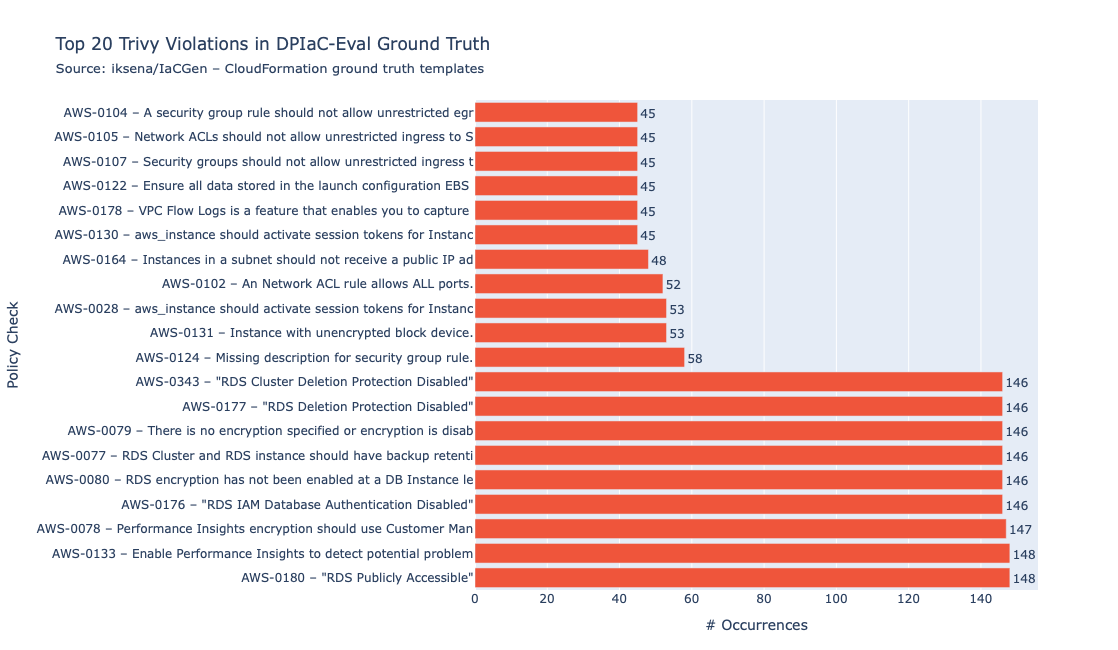

In [39]:
all_violations = []
for vj in df_result['violations_json']:
    try: all_violations.extend(json.loads(vj))
    except: pass

df_viol = pd.DataFrame(all_violations)
if not df_viol.empty:
    df_viol['check_title'] = df_viol['check_id'].map(AVD_TITLE_MAP).fillna(df_viol['check_title'])

top_checks = (
    df_viol.groupby(['check_id','check_title'])
    .size().reset_index(name='count')
    .sort_values('count', ascending=False)
).head(20)

top_checks['label'] = top_checks.apply(
    lambda r: f"{r['check_id']} – {r['check_title'][:55]}", axis=1
)

fig1 = go.Figure(go.Bar(
    x=top_checks['count'], y=top_checks['label'],
    orientation='h', text=top_checks['count'],
    textposition='outside', cliponaxis=False,
    marker_color='#EF553B',
))
fig1.update_layout(
    title="Top 20 Trivy Violations in DPIaC-Eval Ground Truth<br>"
          "<span style='font-size:13px;font-weight:normal;'>"
          "Source: iksena/IaCGen – CloudFormation ground truth templates</span>",
    xaxis_title='# Occurrences', yaxis_title='Policy Check',
    margin=dict(l=420, r=80, t=100, b=60), height=650,
)
fig1.write_image(str(OUTPUT_DIR / 'fig1_top20_violations.png'), scale=2)
fig1.show()
top_checks.to_csv(OUTPUT_DIR / 'top20_violations.csv', index=False)


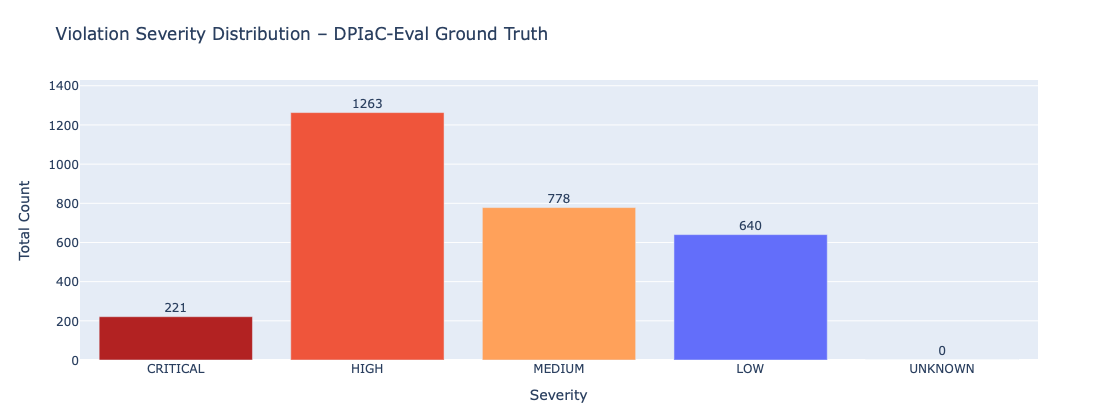

In [41]:
sev_totals = {
    s: int(df_result[c].sum())
    for s, c in [('CRITICAL','severity_critical'),('HIGH','severity_high'),
                 ('MEDIUM','severity_medium'),('LOW','severity_low'),('UNKNOWN','severity_unknown')]
}
fig2 = go.Figure(go.Bar(
    x=list(sev_totals.keys()), y=list(sev_totals.values()),
    marker_color=[SEV_COLORS[s] for s in sev_totals],
    text=list(sev_totals.values()), textposition='outside',
))
fig2.update_layout(
    title='Violation Severity Distribution – DPIaC-Eval Ground Truth',
    xaxis_title='Severity', yaxis_title='Total Count',
    margin=dict(t=80, b=60), height=420,
)
fig2.write_image(str(OUTPUT_DIR / 'fig2_severity_distribution.png'), scale=2)
fig2.show()


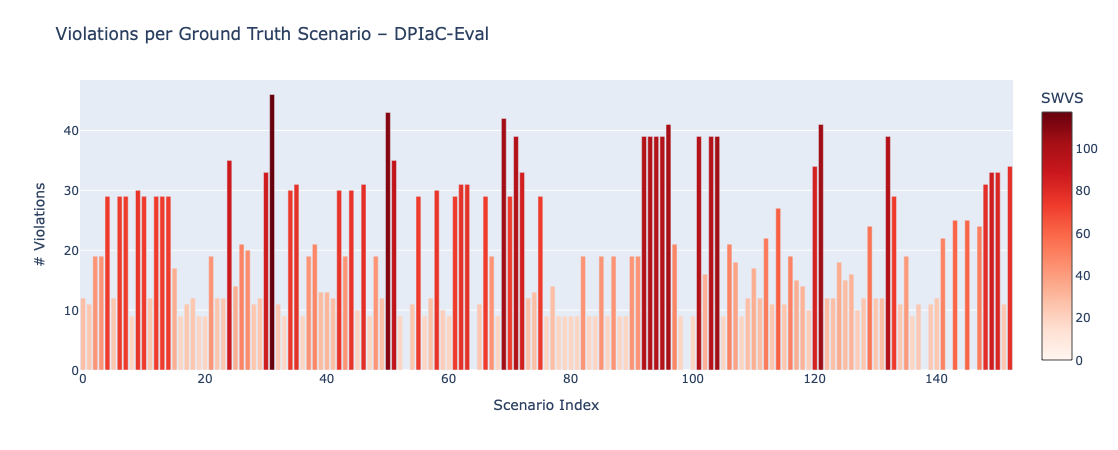

In [43]:
fig3 = go.Figure(go.Bar(
    x=df_result['row_number'],
    y=df_result['failed_checks'],
    marker_color=df_result['swvs'],
    marker_colorscale='Reds',
    marker_colorbar=dict(title='SWVS'),
    text=df_result['template'].str.replace('.yaml','',regex=False),
    hovertemplate=(
        '<b>%{text}</b><br>'
        'Violations: %{y}<br>'
        'SWVS: %{marker.color:.1f}<extra></extra>'
    ),
))
fig3.update_layout(
    title='Violations per Ground Truth Scenario – DPIaC-Eval',
    xaxis_title='Scenario Index', yaxis_title='# Violations',
    margin=dict(t=80, b=80), height=450,
)
fig3.write_image(str(OUTPUT_DIR / 'fig3_per_scenario_violations.png'), scale=2)
fig3.show()


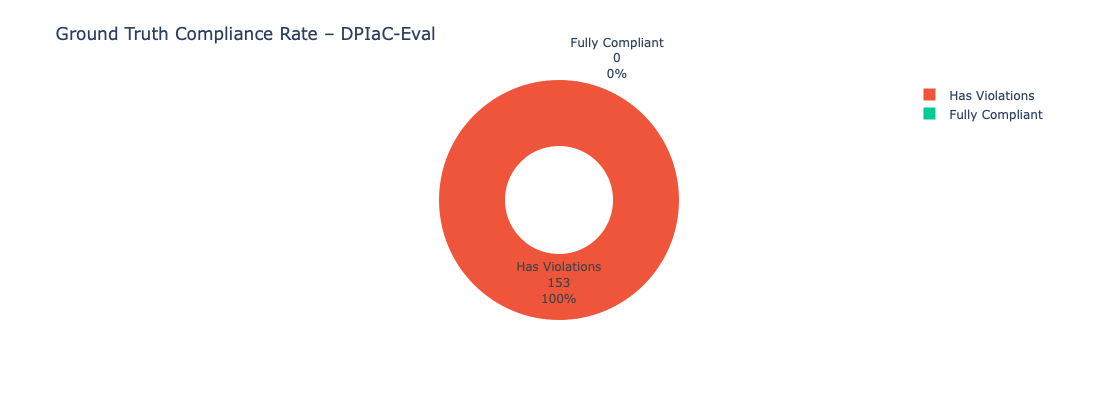

In [45]:
compliant_n   = int(df_result['fully_compliant'].sum())
noncompliant_n = len(df_result) - compliant_n

fig4 = go.Figure(go.Pie(
    labels=['Fully Compliant', 'Has Violations'],
    values=[compliant_n, noncompliant_n],
    marker_colors=['#00CC96', '#EF553B'],
    hole=0.45,
    textinfo='label+percent+value',
))
fig4.update_layout(
    title='Ground Truth Compliance Rate – DPIaC-Eval',
    margin=dict(t=80), height=400,
)
fig4.write_image(str(OUTPUT_DIR / 'fig4_compliance_pie.png'), scale=2)
fig4.show()


In [47]:
save_df = df_result.copy()
for lc in ['violation_ids', 'violation_titles']:
    save_df[lc] = save_df[lc].apply(json.dumps)

save_df.to_csv(OUTPUT_DIR / 'dpiac_gt_trivy_full.csv', index=False)
save_df.to_parquet(OUTPUT_DIR / 'dpiac_gt_trivy_full.parquet')

print(f"All outputs saved → {OUTPUT_DIR}/")
print(f"  dpiac_gt_security_annotations.csv  ← per-scenario violation IDs")
print(f"  dpiac_gt_trivy_full.csv / .parquet  ← full numeric results")
print(f"  top20_violations.csv")
print(f"  fig1_top20_violations.png")
print(f"  fig2_severity_distribution.png")
print(f"  fig3_per_scenario_violations.png")
print(f"  fig4_compliance_pie.png")


All outputs saved → output/dpiac_security_audit/
  dpiac_gt_security_annotations.csv  ← per-scenario violation IDs
  dpiac_gt_trivy_full.csv / .parquet  ← full numeric results
  top20_violations.csv
  fig1_top20_violations.png
  fig2_severity_distribution.png
  fig3_per_scenario_violations.png
  fig4_compliance_pie.png


# Checkov

In [84]:
def run_checkov_cfn(template_path: Path, timeout: int = 120) -> dict:
    result = dict(
        checkov_passed=False, checkov_error=None,
        total_checks=0, passed_checks=0, failed_checks=0,
        policy_pass_rate=None, fully_compliant=False,
        severity_critical=0, severity_high=0, severity_medium=0,
        severity_low=0, severity_unknown=0,
        violations=[], violation_ids=[], violation_titles=[],
    )

    if not template_path.exists():
        result['checkov_error'] = f'file_not_found: {template_path}'
        return result

    cmd = [
        'checkov',
        '--file',      str(template_path),
        '--framework', 'cloudformation',
        '--output',    'json',
        '--quiet',
        '--soft-fail',
        # ← NO --compact: needed to get failed_checks detail array
    ]

    try:
        proc = subprocess.run(
            cmd, capture_output=True, text=True, timeout=timeout
        )
    except subprocess.TimeoutExpired:
        result['checkov_error'] = 'TimeoutExpired'; return result
    except FileNotFoundError:
        result['checkov_error'] = 'checkov_not_found'; return result
    except Exception as e:
        result['checkov_error'] = str(e); return result

    stdout = proc.stdout.strip()
    json_start = re.search(r'[\[\{]', stdout)
    if not json_start:
        result['checkov_error'] = f'no_json: {stdout[:200]}'
        return result

    try:
        raw = json.loads(stdout[json_start.start():])
    except json.JSONDecodeError as e:
        result['checkov_error'] = f'json_parse_failed: {e}'
        return result

    blocks = raw if isinstance(raw, list) else [raw]

    for block in blocks:
        summary = block.get('summary', {})
        results = block.get('results', {})

        # ── Counts always from summary (compact or not) ───────────────────────
        result['passed_checks'] += int(summary.get('passed', 0))
        result['failed_checks'] += int(summary.get('failed', 0))

        # ── Violation details from results.failed_checks ──────────────────────
        for check in results.get('failed_checks', []):
            check_id    = check.get('check_id', '')
            check_title = check.get('check_name', check_id)
            sev         = (check.get('severity') or 'UNKNOWN').upper()
            resource    = check.get('resource', '')
            resource_type = resource.split('.')[0] if '.' in resource else resource

            result['violations'].append({
                'check_id':      check_id,
                'check_title':   check_title,
                'resource':      resource,
                'resource_type': resource_type,
                'severity':      sev,
                'file':          check.get('file_path', str(template_path)),
                'lines':         check.get('file_line_range', []),
                'description':   check.get('description', ''),
                'guideline':     check.get('guideline', ''),
            })
            result['violation_ids'].append(check_id)
            result['violation_titles'].append(check_title)

            sev_col = {
                'CRITICAL': 'severity_critical', 'HIGH': 'severity_high',
                'MEDIUM':   'severity_medium',   'LOW':  'severity_low',
            }.get(sev, 'severity_unknown')
            result[sev_col] += 1

    result['total_checks'] = result['passed_checks'] + result['failed_checks']
    if result['total_checks'] > 0:
        result['policy_pass_rate'] = round(
            result['passed_checks'] / result['total_checks'], 4
        )
    result['fully_compliant'] = (
        result['total_checks'] > 0 and result['failed_checks'] == 0
    )
    result['checkov_passed'] = result['fully_compliant']
    return result

In [86]:
sample = run_checkov_cfn(TEMPLATE_ROOT / 'compliant-bucket.yaml')
print(f"passed : {sample['passed_checks']}")   # expect 32
print(f"failed : {sample['failed_checks']}")   # expect 0
print(f"PPR    : {sample['policy_pass_rate']}") # expect 1.0
print(f"IDs    : {sample['violation_ids']}")    # expect []

passed : 32
failed : 0
PPR    : 1.0
IDs    : []


In [88]:
checkov_results = []
for _, row in tqdm(df.iterrows(), total=len(df),
                   desc='Checkov CFn scan', unit='template'):
    # r = run_checkov_cfn(TEMPLATE_ROOT / row['template'])
    r = run_checkov_cfn(Path(row['template_path']))
    r['row_number'] = row['row_number']
    r['template']   = row['template_path']
    checkov_results.append(r)

CKV_SCALAR_COLS = [
    'checkov_passed', 'checkov_error',
    'total_checks', 'passed_checks', 'failed_checks',
    'policy_pass_rate', 'fully_compliant',
    'severity_critical', 'severity_high', 'severity_medium',
    'severity_low', 'severity_unknown',
]

df_ckv_raw = pd.DataFrame(checkov_results)

df_checkov = df_result[['row_number', 'template', 'prompt']].copy()
for c in CKV_SCALAR_COLS:
    df_checkov[c] = df_ckv_raw[c]
df_checkov['violation_ids']    = df_ckv_raw['violation_ids']
df_checkov['violation_titles'] = df_ckv_raw['violation_titles']
df_checkov['violations_json']  = df_ckv_raw['violations'].apply(json.dumps)

df_checkov['swvs'] = (
    df_checkov['severity_critical'] * 4 + df_checkov['severity_high']     * 3 +
    df_checkov['severity_medium']   * 2 + df_checkov['severity_low']      * 1 +
    df_checkov['severity_unknown']  * 0.5
)

errors = df_checkov[df_checkov['checkov_error'].notna()]
print(f"\nCheckov scan complete")
print(f"  Scenarios scanned     : {len(df_checkov):,}")
print(f"  Scan errors           : {len(errors):,}")
print(f"  Fully compliant (FCR) : {df_checkov['fully_compliant'].sum():,}  "
      f"({df_checkov['fully_compliant'].mean()*100:.1f}%)")
print(f"  Mean PPR              : {df_checkov['policy_pass_rate'].mean()*100:.1f}%")
print(f"  Total violations      : {df_checkov['failed_checks'].sum():,}")
df_checkov.head()

Checkov CFn scan:   0%|          | 0/153 [00:00<?, ?template/s]


Checkov scan complete
  Scenarios scanned     : 153
  Scan errors           : 0
  Fully compliant (FCR) : 19  (12.4%)
  Mean PPR              : 63.4%
  Total violations      : 504


,row_number,template,prompt,checkov_passed,checkov_error,total_checks,passed_checks,failed_checks,policy_pass_rate,fully_compliant,severity_critical,severity_high,severity_medium,severity_low,severity_unknown,violation_ids,violation_titles,violations_json,swvs
0,0,Data\groud_truth\template\sqs_easy.yaml,We need a CloudFormation template that creates...,False,None,1,0,1,0.0000,False,0,0,0,0,1,[CKV_AWS_27],[Ensure all data stored in the SQS queue is en...,"[{""check_id"": ""CKV_AWS_27"", ""check_title"": ""En...",0.5
1,1,Data\groud_truth\template\sns_easy.yaml,We need a CloudFormation template that creates...,False,None,1,0,1,0.0000,False,0,0,0,0,1,[CKV_AWS_26],[Ensure all data stored in the SNS topic is en...,"[{""check_id"": ""CKV_AWS_26"", ""check_title"": ""En...",0.5
2,2,Data\groud_truth\template\s3_easy.yaml,We need a CloudFormation template that creates...,False,None,9,3,6,0.3333,False,0,0,0,0,6,"[CKV_AWS_18, CKV_AWS_53, CKV_AWS_54, CKV_AWS_2...",[Ensure the S3 bucket has access logging enabl...,"[{""check_id"": ""CKV_AWS_18"", ""check_title"": ""En...",3.0
3,3,Data\groud_truth\template\s3_webhost_and_delet...,We need a CloudFormation template that creates...,False,None,9,3,6,0.3333,False,0,0,0,0,6,"[CKV_AWS_18, CKV_AWS_53, CKV_AWS_54, CKV_AWS_2...",[Ensure the S3 bucket has access logging enabl...,"[{""check_id"": ""CKV_AWS_18"", ""check_title"": ""En...",3.0
4,4,Data\groud_truth\template\ec2_easy.yaml,We need a CloudFormation template that creates...,True,None,2,2,0,1.0000,True,0,0,0,0,0,[],[],[],0.0


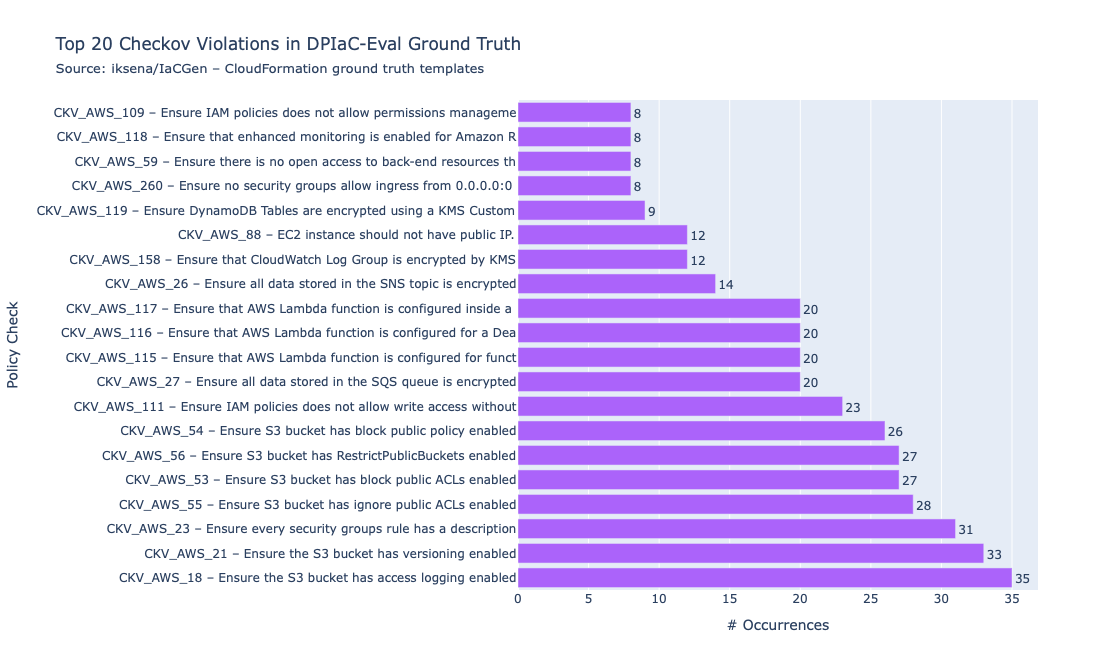

In [90]:
all_ckv_viols = []
for vj in df_checkov['violations_json']:
    try: all_ckv_viols.extend(json.loads(vj))
    except: pass

df_ckv_viol = pd.DataFrame(all_ckv_viols)

ckv_top20 = (
    df_ckv_viol.groupby(['check_id', 'check_title'])
    .size().reset_index(name='count')
    .sort_values('count', ascending=False)
).head(20)

ckv_top20['label'] = ckv_top20.apply(
    lambda r: f"{r['check_id']} – {str(r['check_title'])[:55]}", axis=1
)

fig_ckv1 = go.Figure(go.Bar(
    x=ckv_top20['count'],
    y=ckv_top20['label'],
    orientation='h',
    text=ckv_top20['count'],
    textposition='outside',
    cliponaxis=False,
    marker_color='#AB63FA',
))
fig_ckv1.update_layout(
    title="Top 20 Checkov Violations in DPIaC-Eval Ground Truth<br>"
          "<span style='font-size:13px;font-weight:normal;'>"
          "Source: iksena/IaCGen – CloudFormation ground truth templates</span>",
    xaxis_title='# Occurrences',
    yaxis_title='Policy Check',
    margin=dict(l=440, r=80, t=100, b=60),
    height=650,
)
fig_ckv1.write_image(str(OUTPUT_DIR / 'fig5_checkov_top20.png'), scale=2)
fig_ckv1.show()
ckv_top20.to_csv(OUTPUT_DIR / 'checkov_top20_violations.csv', index=False)


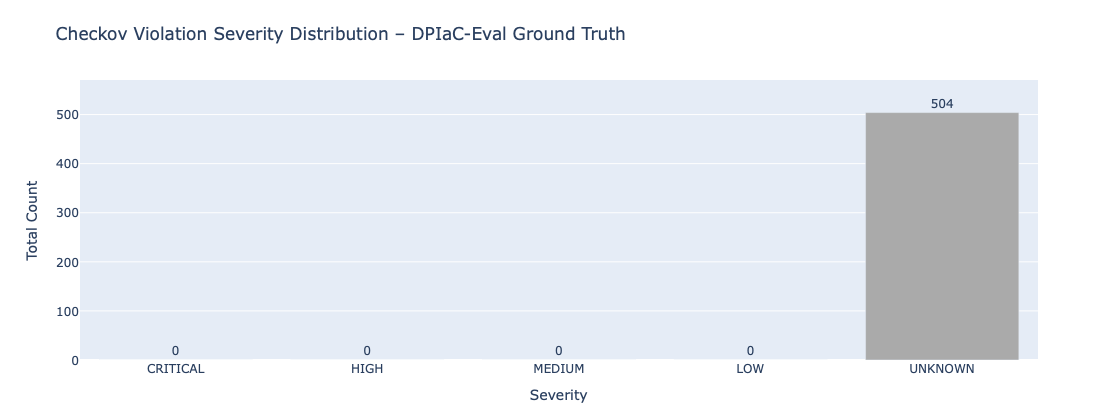

In [92]:
ckv_sev = {s: int(df_checkov[c].sum()) for s, c in [
    ('CRITICAL','severity_critical'), ('HIGH','severity_high'),
    ('MEDIUM','severity_medium'),     ('LOW','severity_low'),
    ('UNKNOWN','severity_unknown'),
]}

fig_ckv2 = go.Figure(go.Bar(
    x=list(ckv_sev.keys()),
    y=list(ckv_sev.values()),
    marker_color=[SEV_COLORS[s] for s in ckv_sev],
    text=list(ckv_sev.values()),
    textposition='outside',
))
fig_ckv2.update_layout(
    title='Checkov Violation Severity Distribution – DPIaC-Eval Ground Truth',
    xaxis_title='Severity', yaxis_title='Total Count',
    margin=dict(t=80, b=60), height=420,
)
fig_ckv2.write_image(str(OUTPUT_DIR / 'fig6_checkov_severity.png'), scale=2)
fig_ckv2.show()


                    Metric Trivy Checkov
   FCR (% fully compliant)  0.0%   12.4%
              Mean PPR (%) 63.0%   63.4%
          Total violations 2,902     504
Mean violations / scenario  19.0     3.3
                  CRITICAL   221       0
                      HIGH 1,263       0
                    MEDIUM   778       0
                       LOW   640       0


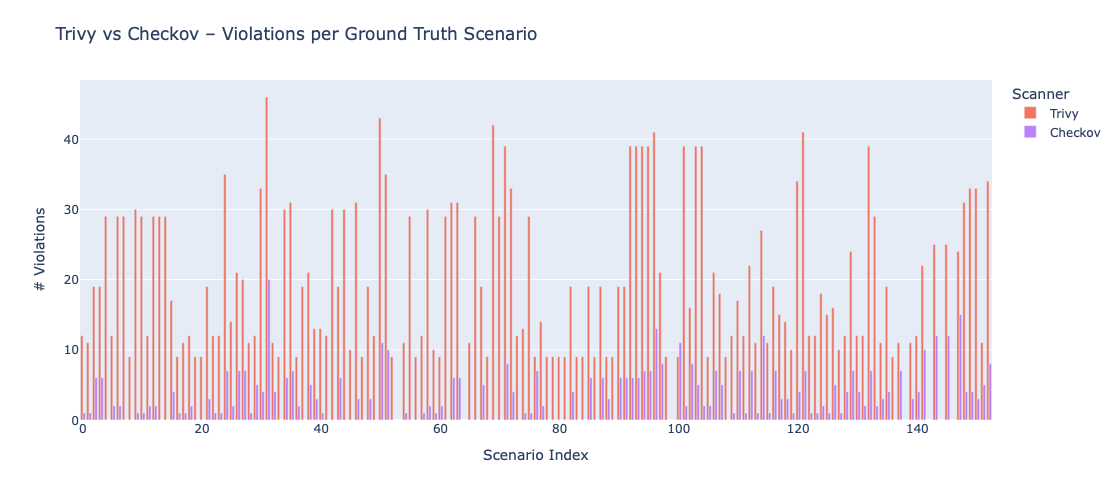

In [94]:
# ── Combined scanner comparison ───────────────────────────────────────────────
compare_df = pd.DataFrame({
    'Metric': [
        'FCR (% fully compliant)', 'Mean PPR (%)',
        'Total violations', 'Mean violations / scenario',
        'CRITICAL', 'HIGH', 'MEDIUM', 'LOW',
    ],
    'Trivy': [
        f"{df_result['fully_compliant'].mean()*100:.1f}%",
        f"{df_result['policy_pass_rate'].mean()*100:.1f}%",
        f"{df_result['failed_checks'].sum():,}",
        f"{df_result['failed_checks'].mean():.1f}",
        f"{df_result['severity_critical'].sum():,}",
        f"{df_result['severity_high'].sum():,}",
        f"{df_result['severity_medium'].sum():,}",
        f"{df_result['severity_low'].sum():,}",
    ],
    'Checkov': [
        f"{df_checkov['fully_compliant'].mean()*100:.1f}%",
        f"{df_checkov['policy_pass_rate'].mean()*100:.1f}%",
        f"{df_checkov['failed_checks'].sum():,}",
        f"{df_checkov['failed_checks'].mean():.1f}",
        f"{df_checkov['severity_critical'].sum():,}",
        f"{df_checkov['severity_high'].sum():,}",
        f"{df_checkov['severity_medium'].sum():,}",
        f"{df_checkov['severity_low'].sum():,}",
    ],
})
print(compare_df.to_string(index=False))

# Grouped bar: violations per scenario for both scanners
fig_cmp = go.Figure()
for scanner, df_s, color in [
    ('Trivy',   df_result,  '#EF553B'),
    ('Checkov', df_checkov, '#AB63FA'),
]:
    fig_cmp.add_trace(go.Bar(
        name=scanner,
        x=df_s['row_number'],
        y=df_s['failed_checks'],
        marker_color=color,
        opacity=0.8,
        hovertemplate=f'<b>{scanner}</b><br>Scenario: %{{x}}<br>Violations: %{{y}}<extra></extra>',
    ))

fig_cmp.update_layout(
    title='Trivy vs Checkov – Violations per Ground Truth Scenario',
    xaxis_title='Scenario Index',
    yaxis_title='# Violations',
    barmode='group',
    legend_title='Scanner',
    margin=dict(t=80, b=60),
    height=480,
)
fig_cmp.write_image(str(OUTPUT_DIR / 'fig7_trivy_vs_checkov.png'), scale=2)
fig_cmp.show()


In [96]:
# ── Merge Trivy + Checkov annotations per scenario ────────────────────────────
df_combined = df_result[['row_number','template','prompt',
                          'failed_checks','policy_pass_rate','fully_compliant']].copy()
df_combined.rename(columns={
    'failed_checks':    'trivy_violations',
    'policy_pass_rate': 'trivy_ppr',
    'fully_compliant':  'trivy_compliant',
}, inplace=True)

df_combined['trivy_violation_ids'] = df_result['violation_ids'].apply(
    lambda ids: ' | '.join(sorted(set(ids))) if ids else '✅ NONE'
)

df_combined['checkov_violations']    = df_checkov['failed_checks']
df_combined['checkov_ppr']           = df_checkov['policy_pass_rate']
df_combined['checkov_compliant']     = df_checkov['fully_compliant']
df_combined['checkov_violation_ids'] = df_checkov['violation_ids'].apply(
    lambda ids: ' | '.join(sorted(set(ids))) if ids else '✅ NONE'
)

# Union of all violation IDs from both scanners
def _union_ids(row):
    t = set(row['trivy_violation_ids'].split(' | ')) if row['trivy_violation_ids'] != '✅ NONE' else set()
    c = set(row['checkov_violation_ids'].split(' | ')) if row['checkov_violation_ids'] != '✅ NONE' else set()
    combined = sorted(t | c)
    return ' | '.join(combined) if combined else '✅ NONE'

df_combined['all_violation_ids'] = df_combined.apply(_union_ids, axis=1)
df_combined['any_violation']     = df_combined['all_violation_ids'] != '✅ NONE'

# Format PPR as percentage strings
df_combined['trivy_ppr_pct']   = (df_combined['trivy_ppr']   * 100).round(1)
df_combined['checkov_ppr_pct'] = (df_combined['checkov_ppr'] * 100).round(1)

# Save
df_combined.drop(columns=['trivy_ppr','checkov_ppr']).to_csv(
    OUTPUT_DIR / 'dpiac_gt_combined_annotations.csv', index=False
)
print(f"Saved → dpiac_gt_combined_annotations.csv")
print(f"  Scenarios with ANY violation: {df_combined['any_violation'].sum()} / {len(df_combined)}")
print(f"\nSample:")
print(df_combined[['row_number','template','trivy_violation_ids','checkov_violation_ids']]
      .head(10).to_string(index=False))


Saved → dpiac_gt_combined_annotations.csv
  Scenarios with ANY violation: 146 / 153

Sample:
 row_number                                                          template                                                                                                                                                                                                                                                                                                                     trivy_violation_ids                                                       checkov_violation_ids
          0                           Data\groud_truth\template\sqs_easy.yaml                                                                                                                                                                                                       AWS-0077 | AWS-0078 | AWS-0079 | AWS-0080 | AWS-0096 | AWS-0097 | AWS-0133 | AWS-0135 | AWS-0176 | AWS-0177 | AWS-0180 | AWS-0343                    

In [98]:
save_ckv = df_checkov.copy()
for lc in ['violation_ids', 'violation_titles']:
    save_ckv[lc] = save_ckv[lc].apply(json.dumps)
save_ckv.to_csv(OUTPUT_DIR / 'dpiac_gt_checkov_full.csv', index=False)
save_ckv.to_parquet(OUTPUT_DIR / 'dpiac_gt_checkov_full.parquet')

print(f"\nAll outputs saved → {OUTPUT_DIR}/")
print(f"  dpiac_gt_combined_annotations.csv   ← PRIMARY: both scanners, per scenario")
print(f"  dpiac_gt_checkov_full.csv / .parquet")
print(f"  checkov_top20_violations.csv")
print(f"  fig5_checkov_top20.png")
print(f"  fig6_checkov_severity.png")
print(f"  fig7_trivy_vs_checkov.png")



All outputs saved → output/dpiac_security_audit/
  dpiac_gt_combined_annotations.csv   ← PRIMARY: both scanners, per scenario
  dpiac_gt_checkov_full.csv / .parquet
  checkov_top20_violations.csv
  fig5_checkov_top20.png
  fig6_checkov_severity.png
  fig7_trivy_vs_checkov.png
